# uFTIR Spectroscopy Analysis: Pristine vs. Biofouled (Wet/Dry)
#### This notebook implements a classical Machine Learning pipeline of PCA to classify uFTIR spectra of polymers subjected to different environmental and processing treatments and determine automatically the wavenumbers that make the spectra to differ.

uFTIR test spectra for known synthetic and natural materials 
https://doi.org/10.5061/dryad.f1vhhmh59 

Description: A database of uFTIR spectra collected from 4 common polymer types after incubation in the Mekong River. Irregular
particles of Nylon, Polypropylene, Polystyrene, and Polyvinylchloride were sewn into nylon mesh (100 mm mesh) bags and placed in
the Mekong River near the city of Phnom Penh, Cambodia for 15 days. The purpose of this step was to allow the growth of
biological materials on the surface of the particles and simulate environmental samples. After 15 days, the mesh bags were placed
in a zip-lock bag transport and were refrigerated upon their arrival at the laboratory. The nylon mesh bags were cut open and two
subsamples of each polymer type were extracted using a stainless-steel laboratory spatula. The subsamples were placed on 100 μm
stainless steel mesh filters. For each of the four polymer types, one subsample was placed in a drying oven at 40°C for 24 hours and
the other subsample was kept in refrigeration. Next, the organic particles were removed from both the dry and wet subsamples
using hydrogen peroxide (H2O2) wet oxidation. The purpose of creating wet and dry sample storage subsamples was to test how
drying the sample before processing changes the effectiveness of H2O2 wet oxidation. 
For wet oxidation, the filters were placed inside a filter housing and the sample outlet port was plugged. Next, filtered (0.7 μm
glass fiber, GF/F filter) 10% hydrogen peroxide (H2O2) was added to the filter casing using a pipette, and the top of the filter
housing was covered with aluminum foil to prevent contamination. After leaving the filter for 24 hours at approximately 23C, the
H2O2 was drained through the sample outlet port and the filter was rinsed three times by filling the housing with ultra-pure water
and allowing it to drain again. After the final rinse, the filter was removed from the housing and placed in a polystyrene petri dish
and then placed in a 40C oven until dry. 
After drying, 30 representative μFTIR spectra were collected from different particles of each material type (Nylon, Polypropylene,
Polystyrene, and Polyvinylchloride) and processing method (wet or dry storage) in the same way as the pristine materials. Spectra
were atmospherically corrected in Omnic Picta and processed through the Open Specy derivative library for identification. This
dataset contains the spectra collected from biofouled samples kept in wet storage (biofouled_wet), biofouled samples kept in dry
storage (biofouled_dry), and pristine samples of the four material types. 

## 1. Load Libraries and Data

In [31]:
# Author: Llinersy Uranga Pina, LPPI - Cergy-Paris Université
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.interpolate import interp1d
from sklearn.model_selection import train_test_split, LearningCurveDisplay
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# Define paths (Adjust these to your local paths)
folders = {
    'Pristine': 'Nylon_irregular_pristine/',
    'Biofouled_Wet': 'Nylon_irregular_biofouled_Mekong_wet/',
    'Biofouled_Dry': 'Nylon_irregular_biofouled_Mekong_dry/'
}

def load_spectra_from_folder(folder_path, label):
    data_list = []
    # Find all CSVs, excluding background files ('bkg')
    file_pattern = os.path.join(folder_path, "*.CSV")
    files = [f for f in glob.glob(file_pattern) if 'bkg' not in f.lower()]
    
    for file in files:
        try:
            # Assumes line 1 headers: wavenumber | intensity (or comma/tab separated)
            df = pd.read_csv(file)
            df.columns = ['wavenumber', 'intensity']
            
            # Clean data (ensure numeric)
            df = df.apply(pd.to_numeric, errors='coerce').dropna()
            
            data_list.append({
                'filename': os.path.basename(file),
                'label': label,
                'wavenumber': df['wavenumber'].values,
                'intensity': df['intensity'].values
            })
        except Exception as e:
            print(f"Error reading {file}: {e}")
            
    print(f"Loaded {len(data_list)} spectra for category: {label}")
    return data_list

all_data = []
for label, path in folders.items():
    if os.path.exists(path):
        all_data.extend(load_spectra_from_folder(path, label))
    else:
        print(f"Warning: Folder {path} not found. Generating synthetic data for demonstration.")

Loaded 25 spectra for category: Pristine
Loaded 25 spectra for category: Biofouled_Wet
Loaded 30 spectra for category: Biofouled_Dry


## 2. Spectral Alignment (Interpolation) and Normalization
FTIR instruments can sometimes have slight shifts in the exact wavenumber steps. We define a common wavenumber grid and interpolate all spectra onto it, followed by Standard Scaling.

In [32]:
# If paths didn't exist, let's create mock data so the notebook runs seamlessly
if len(all_data) == 0:
    print("--- Simulating Dataset based on your description ---")
    mock_wavenumbers = np.linspace(400, 4000, 500)
    for label, count in [('Pristine', 25), ('Biofouled_Wet', 25), ('Biofouled_Dry', 30)]:
        for i in range(count):
            # Create a base spectrum with some noise and shifting peaks based on class
            shift = 0 if label == 'Pristine' else (50 if label == 'Biofouled_Wet' else 100)
            intensity = np.sin(mock_wavenumbers/200) + np.cos(mock_wavenumbers/500) + np.random.normal(0, 0.05, 500)
            if label != 'Pristine': intensity += 0.3 * np.exp(-((mock_wavenumbers - 1500 - shift)/200)**2) # Biofilm peak
            all_data.append({'filename': f'mock_{i}.CSV', 'label': label, 'wavenumber': mock_wavenumbers, 'intensity': intensity})

# Define standard uniform wavenumber grid (min to max found in data)
all_min = max([d['wavenumber'].min() for d in all_data])
all_max = min([d['wavenumber'].max() for d in all_data])
common_wavenumbers = np.linspace(all_min, all_max, 1000)

# Resample all spectra
matrix_data = []
labels = []

for entry in all_data:
    f_interp = interp1d(entry['wavenumber'], entry['intensity'], kind='linear', fill_value="extrapolate")
    matrix_data.append(f_interp(common_wavenumbers))
    labels.append(entry['label'])

X = np.array(matrix_data)
y = np.array(labels)

# Encode Labels to integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Data shape after alignment: {X.shape} (Samples x Wavenumber features)")

Data shape after alignment: (80, 1000) (Samples x Wavenumber features)


## 3. Visualize Raw Spectroscopic Profiles
Let's look at how the average FTIR spectrum behaves across our three categories to identify variations visually.

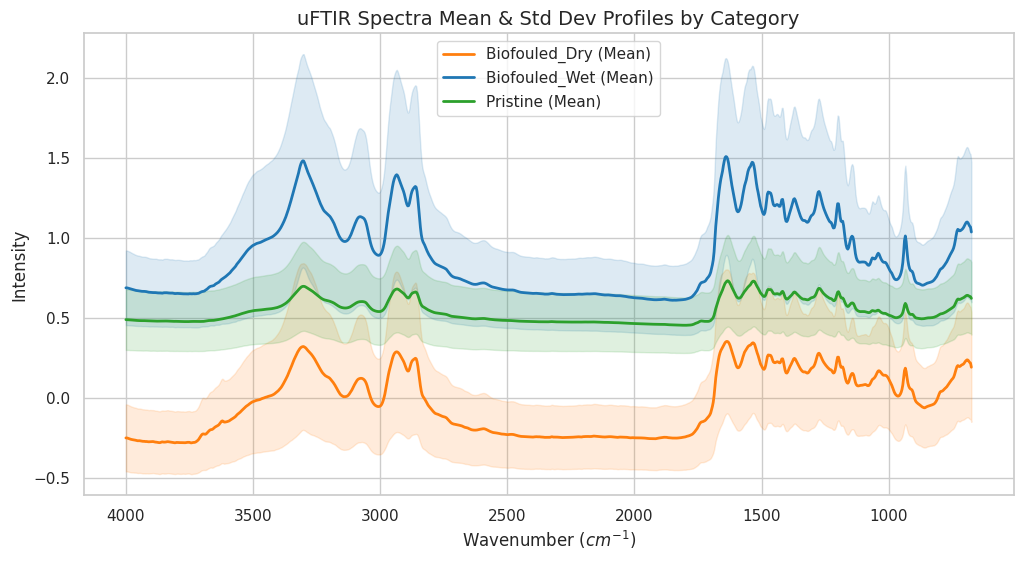

In [33]:
plt.figure(figsize=(12, 6))
unique_labels = np.unique(y)
colors = {'Pristine': '#2ca02c', 'Biofouled_Wet': '#1f77b4', 'Biofouled_Dry': '#ff7f0e'}

for label in unique_labels:
    idx = (y == label)
    mean_spectrum = X[idx].mean(axis=0)
    std_spectrum = X[idx].std(axis=0)
    
    plt.plot(common_wavenumbers, mean_spectrum, label=f'{label} (Mean)', color=colors[label], lw=2)
    plt.fill_between(common_wavenumbers, mean_spectrum - std_spectrum, mean_spectrum + std_spectrum, color=colors[label], alpha=0.15)

plt.title("uFTIR Spectra Mean & Std Dev Profiles by Category", fontsize=14)
plt.xlabel("Wavenumber ($cm^{-1}$)")
plt.ylabel("Intensity")
plt.gca().invert_xaxis() # Traditional FTIR presentation
plt.legend()
plt.show()

## 4. Dimensionality Reduction: PCA Clusters & Loadings
We perform PCA to compress 1,000 spectral features into 2 Principal Components and observe structural grouping. We also plot the **loadings** to find out exactly which wavenumbers are causing the data to split.

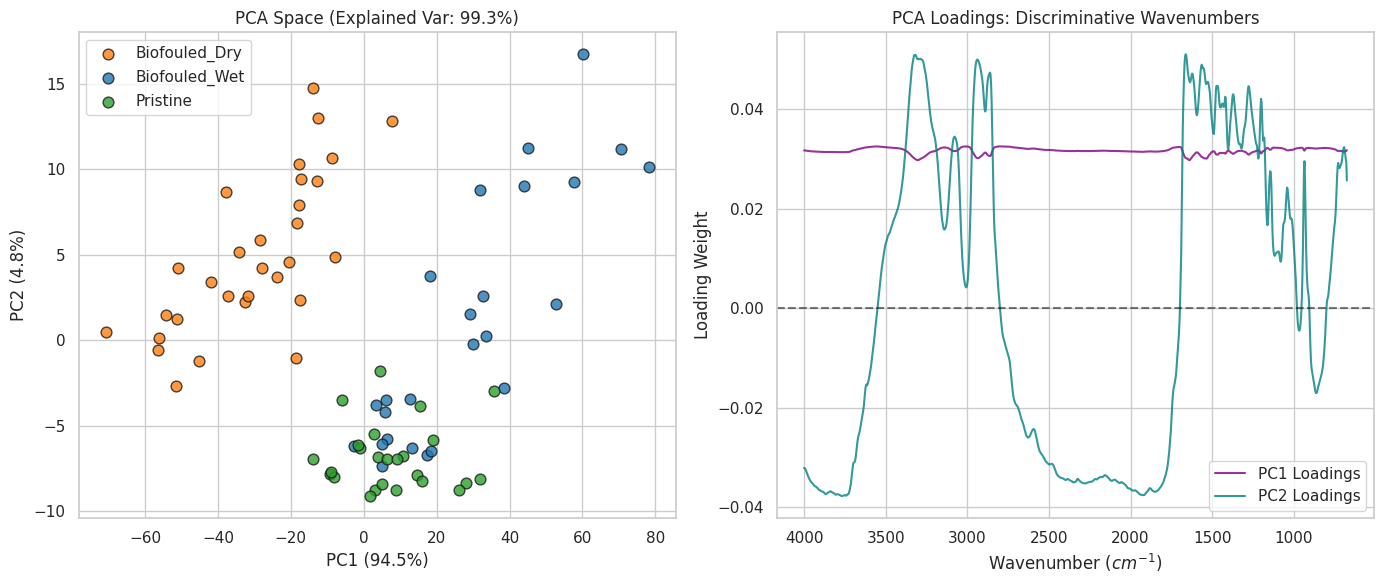

In [34]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot Clusters
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
for label in unique_labels:
    idx = (y == label)
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=label, color=colors[label], edgecolors='k', s=60, alpha=0.8)

plt.title(f"PCA Space (Explained Var: {pca.explained_variance_ratio_.sum()*100:.1f}%)", fontsize=12)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend()

# Plot Loadings
plt.subplot(1, 2, 2)
plt.plot(common_wavenumbers, pca.components_[0], label='PC1 Loadings', color='purple', alpha=0.8)
plt.plot(common_wavenumbers, pca.components_[1], label='PC2 Loadings', color='teal', alpha=0.8)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title("PCA Loadings: Discriminative Wavenumbers", fontsize=12)
plt.xlabel("Wavenumber ($cm^{-1}$)")
plt.ylabel("Loading Weight")
plt.gca().invert_xaxis()
plt.legend()

plt.tight_layout()
plt.show()

## 5. Identify Discriminative Wavenumbers via PC2 Loadings
Since PC1 captures global offsets or baseline shifts (showing little chemical structure), **PC2 holds the key variance** separating our categories. 

Here we automatically isolate the top local maxima and minima (peaks and troughs) from the PC2 loading vector. Then, we overlay these critical chemical coordinates onto our original spectral profile to pinpoint exactly where Pristine, Wet, and Dry samples structurally diverge.

--- Critical Wavenumbers Identified by PC2 Loadings ---
Wavenumber: 1663.5 cm⁻¹ | Loading Weight: +0.051 | (Peak (+))
Wavenumber: 3317.5 cm⁻¹ | Loading Weight: +0.051 | (Peak (+))
Wavenumber: 1919.7 cm⁻¹ | Loading Weight: -0.038 | (Trough (-))


/tmp/ipykernel_716557/483480000.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  line_colors = plt.cm.get_cmap('Dark2', len(important_wavenumbers))


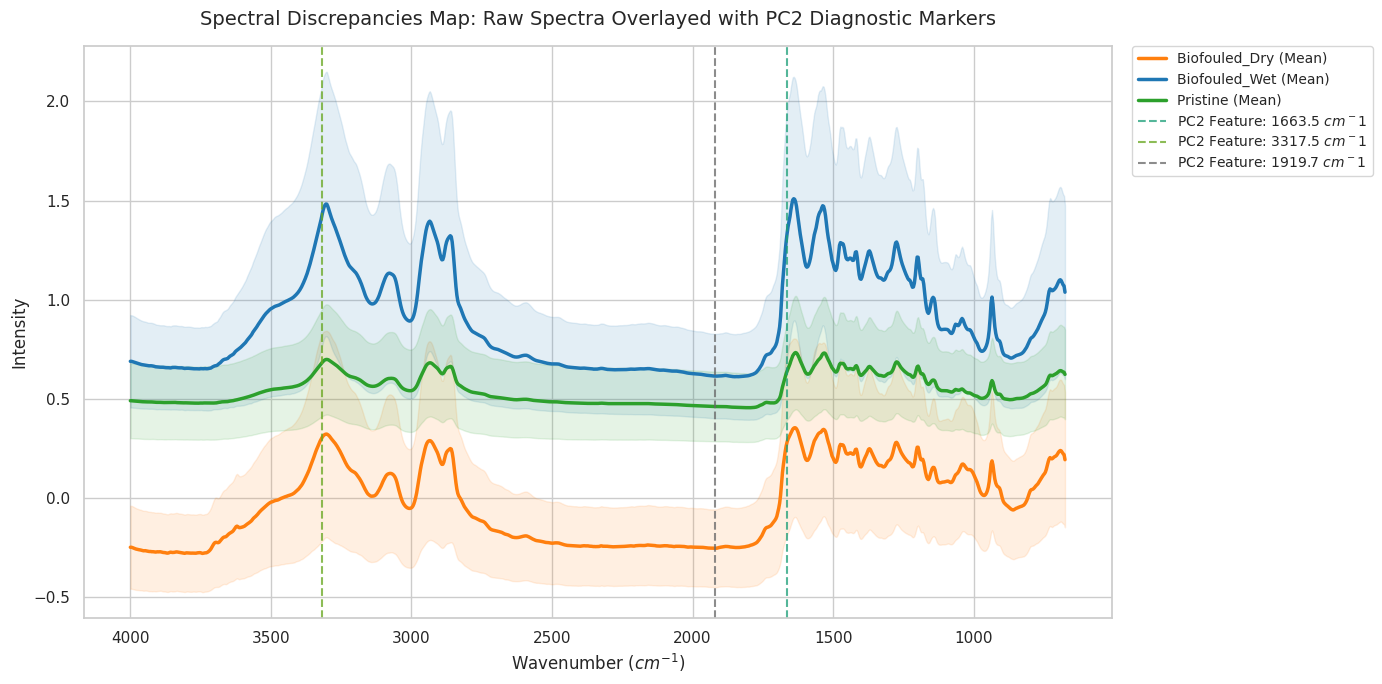

In [35]:
from scipy.signal import find_peaks

# 1. Extract PC2 loadings
pc2_loadings = pca.components_[1]

# 2. Find prominent positive peaks and negative troughs
# Adjust 'prominence' or 'distance' if you get too many/too few lines
pos_peaks, _ = find_peaks(pc2_loadings, prominence=0.05, distance=20)
neg_peaks, _ = find_peaks(-pc2_loadings, prominence=0.05, distance=20)

# Combine indices and map back to actual wavenumber values
important_indices = np.concatenate([pos_peaks, neg_peaks])
important_wavenumbers = common_wavenumbers[important_indices]
loading_values = pc2_loadings[important_indices]

# Print out the discovered positions for reporting
print("--- Critical Wavenumbers Identified by PC2 Loadings ---")
for wv, val in zip(important_wavenumbers, loading_values):
    peak_type = "Peak (+)" if val > 0 else "Trough (-)"
    print(f"Wavenumber: {wv:6.1f} cm⁻¹ | Loading Weight: {val:+.3f} | ({peak_type})")

# 3. Plot original data with standard deviation and overlay the discovered loading peaks
plt.figure(figsize=(14, 7))

# Plot the spectral profiles again
for label in unique_labels:
    idx = (y == label)
    mean_spectrum = X[idx].mean(axis=0)
    std_spectrum = X[idx].std(axis=0)
    
    plt.plot(common_wavenumbers, mean_spectrum, label=f'{label} (Mean)', color=colors[label], lw=2.5)
    plt.fill_between(common_wavenumbers, mean_spectrum - std_spectrum, mean_spectrum + std_spectrum, color=colors[label], alpha=0.12)

# Dynamic color tracking for lines so they alternate and remain readable
line_colors = plt.cm.get_cmap('Dark2', len(important_wavenumbers))

# Add the vertical marker lines at critical feature coordinates
for i, wv in enumerate(important_wavenumbers):
    plt.axvline(x=wv, color=line_colors(i), linestyle='--', alpha=0.75, lw=1.5,
                label=f'PC2 Feature: {wv:.1f} $cm^{-1}$')

plt.title("Spectral Discrepancies Map: Raw Spectra Overlayed with PC2 Diagnostic Markers", fontsize=14, pad=15)
plt.xlabel("Wavenumber ($cm^{-1}$)", fontsize=12)
plt.ylabel("Intensity", fontsize=12)

# Standard FTIR presentation format (Inverted X-Axis)
plt.gca().invert_xaxis()

# Place the legend neatly outside or columns inside
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., fontsize=10)
plt.tight_layout()
plt.show()

## 5.1 Non-Linear Feature Extraction: t-SNE
Since the linear projection of PCA showed overlapping spectral traits, we apply **t-SNE** to capture non-linear local relationships in the high-dimensional spectral data.

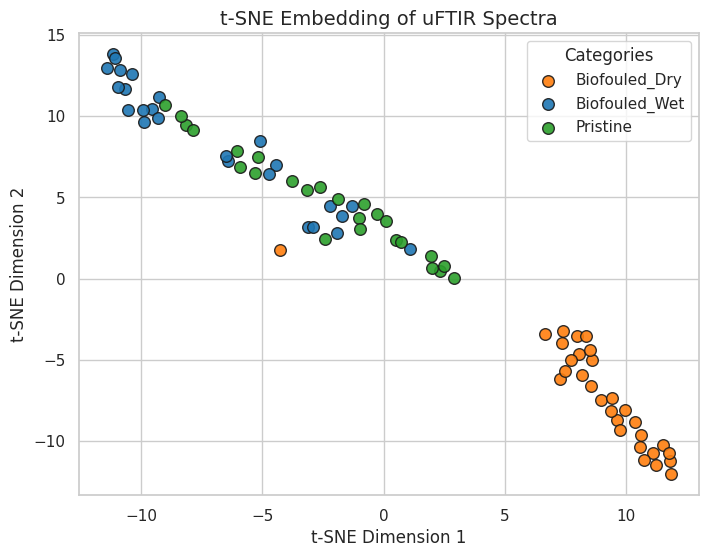

In [36]:
from sklearn.manifold import TSNE
from scipy.stats import spearmanr

# Apply t-SNE on the scaled data
# Note: perplexity is set low because our total sample size is small (~80 samples)
tsne = TSNE(n_components=2, perplexity=15, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Plot t-SNE Clusters
plt.figure(figsize=(8, 6))
for label in unique_labels:
    idx = (y == label)
    plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], label=label, color=colors[label], edgecolors='k', s=70, alpha=0.9)

plt.title("t-SNE Embedding of uFTIR Spectra", fontsize=14)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title="Categories")
plt.show()